In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Detect environment
if Path("/kaggle/input").exists():
    DATA_DIR = Path("/kaggle/input/ieee-fraud-detection")
else:
    DATA_DIR = Path("data/raw")

print("Using data directory:", DATA_DIR)

for file_path in DATA_DIR.iterdir():
    print(file_path)

Using data directory: data\raw
data\raw\test_identity.csv
data\raw\test_transaction.csv
data\raw\train_identity.csv
data\raw\train_transaction.csv


# Dagshub/Mlflow initialization

In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='myvari', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

Accessing as myvari

Initialized MLflow to track repo "myvari/IEEE-CIS-Fraud-Detection"

Repository myvari/IEEE-CIS-Fraud-Detection initialized!

# Exploratory Data Analysis

In [4]:
df_transaction = pd.read_csv(DATA_DIR / 'train_transaction.csv')
df_identity = pd.read_csv(DATA_DIR / 'train_identity.csv')

# df_transaction.columns = df_transaction.columns.str.replace("id_", "id-", regex=False)
# df_identity.columns = df_identity.columns.str.replace("id_", "id-", regex=False)

In [5]:
from sklearn.model_selection import train_test_split
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')


df = df.sort_values("TransactionDT").reset_index(drop=True)

X = df.drop(columns=['isFraud'])
y = df['isFraud']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )   

split_index = int(len(df) * 0.8) # time-aware split

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()


print(f"Transaction train shape: {df_transaction.shape}")
print(f"Identity train shape:    {df_identity.shape}")
print(f"Merged train shape:      {df.shape}")
print(f"X_train size:            {X_train.shape}")
print(f"X_test size:             {X_test.shape}")

print(f"Train TransactionDT range: {X_train['TransactionDT'].min()} - {X_train['TransactionDT'].max()}")
print(f"Test TransactionDT range: {X_test['TransactionDT'].min()} - {X_test['TransactionDT'].max()}")

print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

Transaction train shape: (590540, 394)
Identity train shape:    (144233, 41)
Merged train shape:      (590540, 434)
X_train size:            (472432, 433)
X_test size:             (118108, 433)
Train TransactionDT range: 86400 - 12192842
Test TransactionDT range: 12192900 - 15811131
Train fraud rate: 3.5135%
Test fraud rate: 3.4409%


In [6]:
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

Train fraud rate: 3.5135%
Test fraud rate: 3.4409%


In [7]:
identity_coverage = df_identity["TransactionID"].nunique() / df_transaction["TransactionID"].nunique()

print(f"Identity coverage in train: {identity_coverage:.2%}")

Identity coverage in train: 24.42%


In [8]:
X_train.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [9]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,472432.0,3.223216e+06,1.363795e+05,2987000.000,3105107.75,3223215.50,3341323.25,3.459431e+06
TransactionDT,472432.0,5.715961e+06,3.559869e+06,86400.000,2310158.25,5592303.50,8745778.50,1.219284e+07
TransactionAmt,472432.0,1.344014e+02,2.375580e+02,0.251,42.95,68.95,125.00,3.193739e+04
card1,472432.0,9.867868e+03,4.899160e+03,1000.000,6019.00,9633.00,14128.00,1.839600e+04
card2,465407.0,3.628612e+02,1.580709e+02,100.000,210.00,361.00,512.00,6.000000e+02
...,...,...,...,...,...,...,...,...
id_22,4273.0,1.600842e+01,6.922249e+00,10.000,14.00,14.00,14.00,4.400000e+01
id_24,3914.0,1.276392e+01,2.200403e+00,11.000,11.00,11.00,15.00,2.600000e+01
id_25,4246.0,3.300975e+02,9.923713e+01,100.000,321.00,321.00,371.00,5.480000e+02
id_26,4267.0,1.482620e+02,3.235351e+01,100.000,119.00,147.00,169.00,2.160000e+02


In [10]:
X_train.describe(include="object").T

,count,unique,top,freq
ProductCD,472432,5,W,346001
card4,471599,4,visa,308141
card6,471604,4,debit,349843
P_emaildomain,398846,59,gmail.com,182692
R_emaildomain,113620,60,gmail.com,47290
M1,234137,2,T,234116
M2,234137,2,T,210007
M3,234137,2,T,184780
M4,245241,3,M0,155071
M5,188918,2,F,104333


In [11]:
X_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472432 entries, 0 to 472431
Data columns (total 433 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   472432 non-null  int64  
 1    TransactionDT   472432 non-null  int64  
 2    TransactionAmt  472432 non-null  float64
 3    ProductCD       472432 non-null  object 
 4    card1           472432 non-null  int64  
 5    card2           465407 non-null  float64
 6    card3           471609 non-null  float64
 7    card4           471599 non-null  object 
 8    card5           469279 non-null  float64
 9    card6           471604 non-null  object 
 10   addr1           418671 non-null  float64
 11   addr2           418671 non-null  float64
 12   dist1           185275 non-null  float64
 13   dist2           32100 non-null   float64
 14   P_emaildomain   398846 non-null  object 
 15   R_emaildomain   113620 non-null  object 
 16   C1              472432 non-null  flo

In [12]:
missing_summary =  (
    X_train.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame(name="missing_percentage")
)

missing_summary.head(30)

,missing_percentage
id_24,99.171521
id_25,99.101246
id_08,99.098071
id_07,99.098071
id_21,99.097648
id_26,99.096801
id_22,99.095531
id_27,99.095531
id_23,99.095531
D7,93.661733


Columns with more than 10% missing: 322
Columns with more than 25% missing: 252
Columns with more than 50% missing: 229
Columns with more than 75% missing: 206
Columns with more than 90% missing: 12


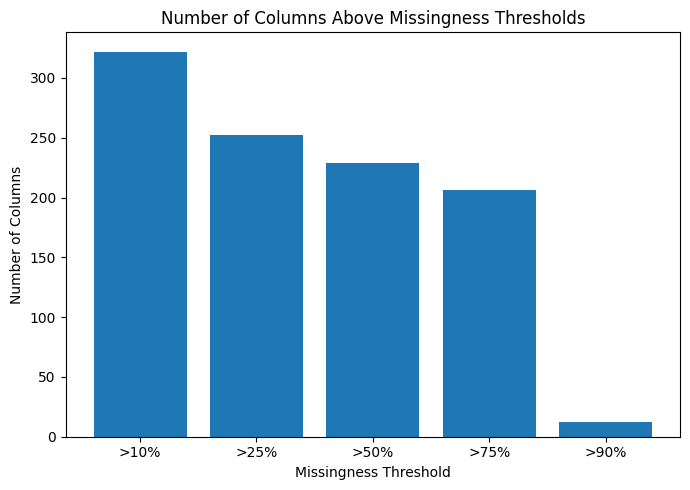

In [13]:
import matplotlib.pyplot as plt

for threshold in [10, 25, 50, 75, 90]:
    count = (missing_summary["missing_percentage"] > threshold).sum()
    print(f"Columns with more than {threshold}% missing: {count}")

thresholds = [10, 25, 50, 75, 90]
counts = [
    (missing_summary["missing_percentage"] > threshold).sum()
    for threshold in thresholds
]

plt.figure(figsize=(7, 5))
plt.bar([f">{t}%" for t in thresholds], counts)
plt.xlabel("Missingness Threshold")
plt.ylabel("Number of Columns")
plt.title("Number of Columns Above Missingness Thresholds")
plt.tight_layout()
plt.show()

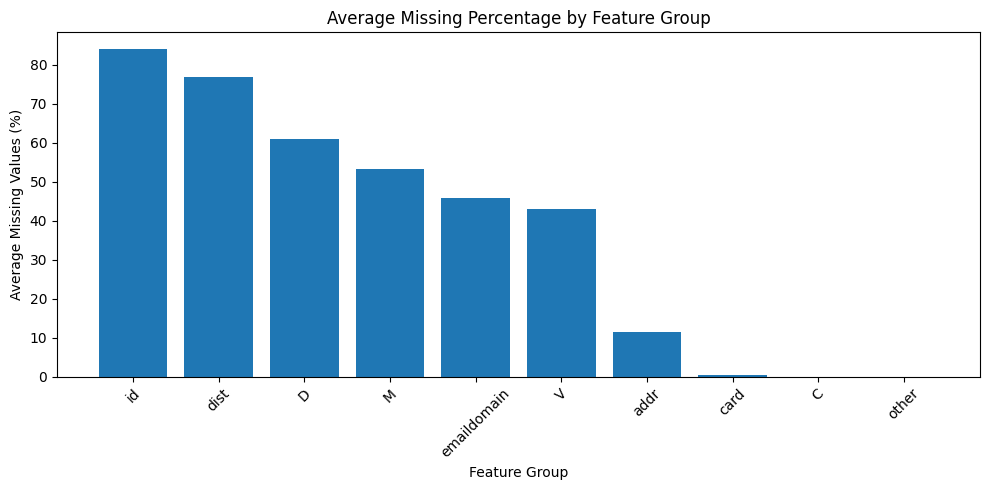

,count,mean,median,min,max
group,,,,,
id,38,84.147231,81.649528,74.501304,99.171521
dist,2,76.994044,76.994044,60.782716,93.205371
D,17,61.075133,75.099485,0.198124,93.661733
M,9,53.315915,50.440063,29.933408,63.496969
emaildomain,2,45.762988,45.762988,15.575998,75.949978
V,339,42.992148,52.065271,0.002540,85.245707
addr,2,11.379627,11.379627,11.379627,11.379627
card,6,0.446696,0.175792,0.000000,1.486986
C,14,0.000000,0.000000,0.000000,0.000000


In [14]:
def get_feature_group(col):
    if col.startswith("V"):
        return "V"
    elif col.startswith("id_"):
        return "id"
    elif col.startswith("D"):
        return "D"
    elif col.startswith("C"):
        return "C"
    elif col.startswith("M"):
        return "M"
    elif col.startswith("card"):
        return "card"
    elif col.startswith("addr"):
        return "addr"
    elif "emaildomain" in col:
        return "emaildomain"
    elif col.startswith("dist"):
        return "dist"
    else:
        return "other"

missing_by_group = missing_summary.copy()
missing_by_group["group"] = missing_by_group.index.map(get_feature_group)

group_missing_summary = (
    missing_by_group
    .groupby("group")["missing_percentage"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(group_missing_summary.index, group_missing_summary["mean"])
plt.ylabel("Average Missing Values (%)")
plt.xlabel("Feature Group")
plt.title("Average Missing Percentage by Feature Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

group_missing_summary

In [15]:
v_cols = [col for col in X_train.columns if col.startswith("V")]
c_cols = [col for col in X_train.columns if col.startswith("C")]
d_cols = [col for col in X_train.columns if col.startswith("D")]
id_cols = [col for col in X_train.columns if col.startswith("id_")]

feature_groups_by_missingness = pd.DataFrame({
    "group": ["V columns", "C columns", "D columns", "id columns"],
    "count": [len(v_cols), len(c_cols), len(d_cols), len(id_cols)],
    "avg_missing_percentage": [
        X_train[v_cols].isna().mean().mean() * 100,
        X_train[c_cols].isna().mean().mean() * 100,
        X_train[d_cols].isna().mean().mean() * 100,
        X_train[id_cols].isna().mean().mean() * 100,
    ]
})

feature_groups_by_missingness.sort_values("avg_missing_percentage", ascending=False)

,group,count,avg_missing_percentage
3,id columns,38,84.147231
2,D columns,17,61.075133
0,V columns,339,42.992148
1,C columns,14,0.000000


In [16]:
print(f"Duplicated rows in X_train: {X_train.duplicated().sum()}")
print(f"Duplicated TransactionID values: {X_train['TransactionID'].duplicated().sum()}")

Duplicated rows in X_train: 0
Duplicated TransactionID values: 0


In [17]:
target_summary = pd.DataFrame({
    "count": y_train.value_counts(),
    "ratio": y_train.value_counts(normalize=True)
})
target_summary.index = ["Not Fraud", "Fraud"]

target_summary

,count,ratio
Not Fraud,455833,0.964865
Fraud,16599,0.035135


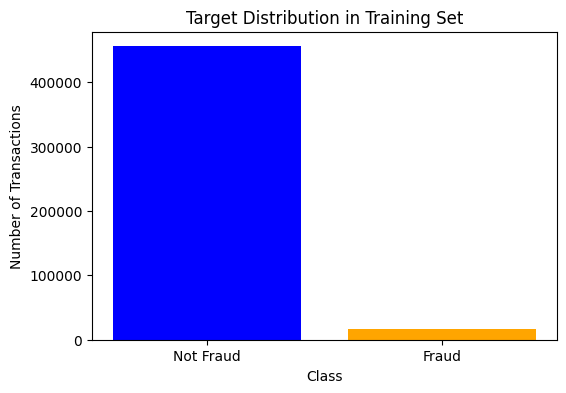

In [18]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Fraud", "Fraud"], class_counts.values, color=["blue", "orange"])
plt.title("Target Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
majority_class_accuracy = 1 - y_train.mean()

print(f"Accuracy of always predicting non-fraud: {majority_class_accuracy:.4%}")

Accuracy of always predicting non-fraud: 96.4865%


---

- Identity coverage: about 24.4%
- Fraud class ratio: about 3.5%
- Columns with >50% missing: 214
- Columns with >75% missing: 208
- Columns with >90% missing: 12
- Duplicated rows: 0
- Duplicated TransactionID values: 0

Strong imbalance, missing values might cause major modeling issues if not addressed, TransactionID is unique no dup rows from merge. 


---

In [20]:
eda_train = df
eda_train["has_identity"] = eda_train["id_01"].notna().astype(int)

identity_fraud_summary = eda_train.groupby("has_identity")["isFraud"].agg(
    count="count",
    fraud_count="sum",
    fraud_rate="mean"
)

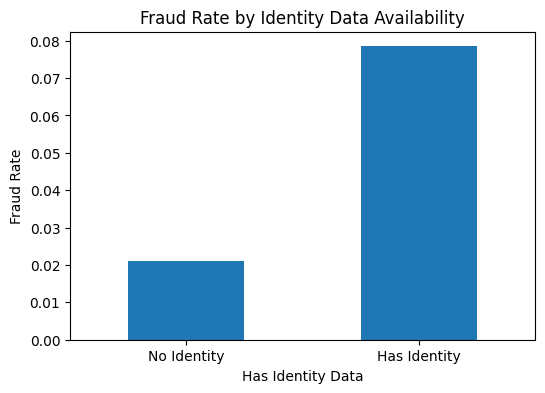

In [21]:
identity_fraud_summary["fraud_rate"].plot(kind="bar", figsize=(6, 4))

plt.title("Fraud Rate by Identity Data Availability")
plt.xlabel("Has Identity Data")
plt.ylabel("Fraud Rate")
plt.xticks(ticks=[0, 1], labels=["No Identity", "Has Identity"], rotation=0)
plt.show()

In [22]:
missing_signal = [] # column missingness signal analysis

for col in X_train.columns:
    missing_flag = X_train[col].isna()

    if missing_flag.nunique() == 2:
        fraud_rate_missing = y_train[missing_flag].mean()
        fraud_rate_present = y_train[~missing_flag].mean()
        missing_pct = missing_flag.mean() * 100

        missing_signal.append({
            "feature": col,
            "missing_percentage": missing_pct,
            "fraud_rate_missing": fraud_rate_missing,
            "fraud_rate_present": fraud_rate_present,
            "absolute_diff": abs(fraud_rate_missing - fraud_rate_present),
            "ratio_missing_to_present": fraud_rate_missing / fraud_rate_present if fraud_rate_present > 0 else np.nan
        })

missing_signal_df = pd.DataFrame(missing_signal)

# ignore tiny missing groups
reliable_missing_signal = (
    missing_signal_df[ 
        (missing_signal_df["missing_percentage"] >= 1) &
        (missing_signal_df["missing_percentage"] <= 99)
    ]
    .sort_values(by="absolute_diff", ascending=False)
    .reset_index(drop=True)
)

reliable_missing_signal.head(30)

,feature,missing_percentage,fraud_rate_missing,fraud_rate_present,absolute_diff,ratio_missing_to_present
0,D7,93.661733,0.027384,0.149679,0.122296,0.182950
1,addr2,11.379627,0.113986,0.025010,0.088976,4.557599
2,addr1,11.379627,0.113986,0.025010,0.088976,4.557599
3,D14,89.451180,0.025762,0.114616,0.088854,0.224770
4,D12,88.844320,0.025269,0.113713,0.088444,0.222215
5,D13,89.633852,0.026642,0.108570,0.081928,0.245394
6,id_04,88.550733,0.026184,0.104363,0.078179,0.250896
7,id_03,88.550733,0.026184,0.104363,0.078179,0.250896
8,D6,87.620864,0.025530,0.103124,0.077594,0.247563
9,id_09,86.958970,0.025198,0.101396,0.076198,0.248514


For several identity features the availability of feature itself is associated with higher fraud probability.

Several feature blocks show correlated (1.0 even) missingness behaviour, especially among V and identity columns. Many of these features are generated or grouped so missing indicators may be redundant and should later be combined with feature selection or regularization.

In [23]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_cols_no_id = [col for col in numerical_cols if col != "TransactionID"]

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 402
Categorical columns: 31


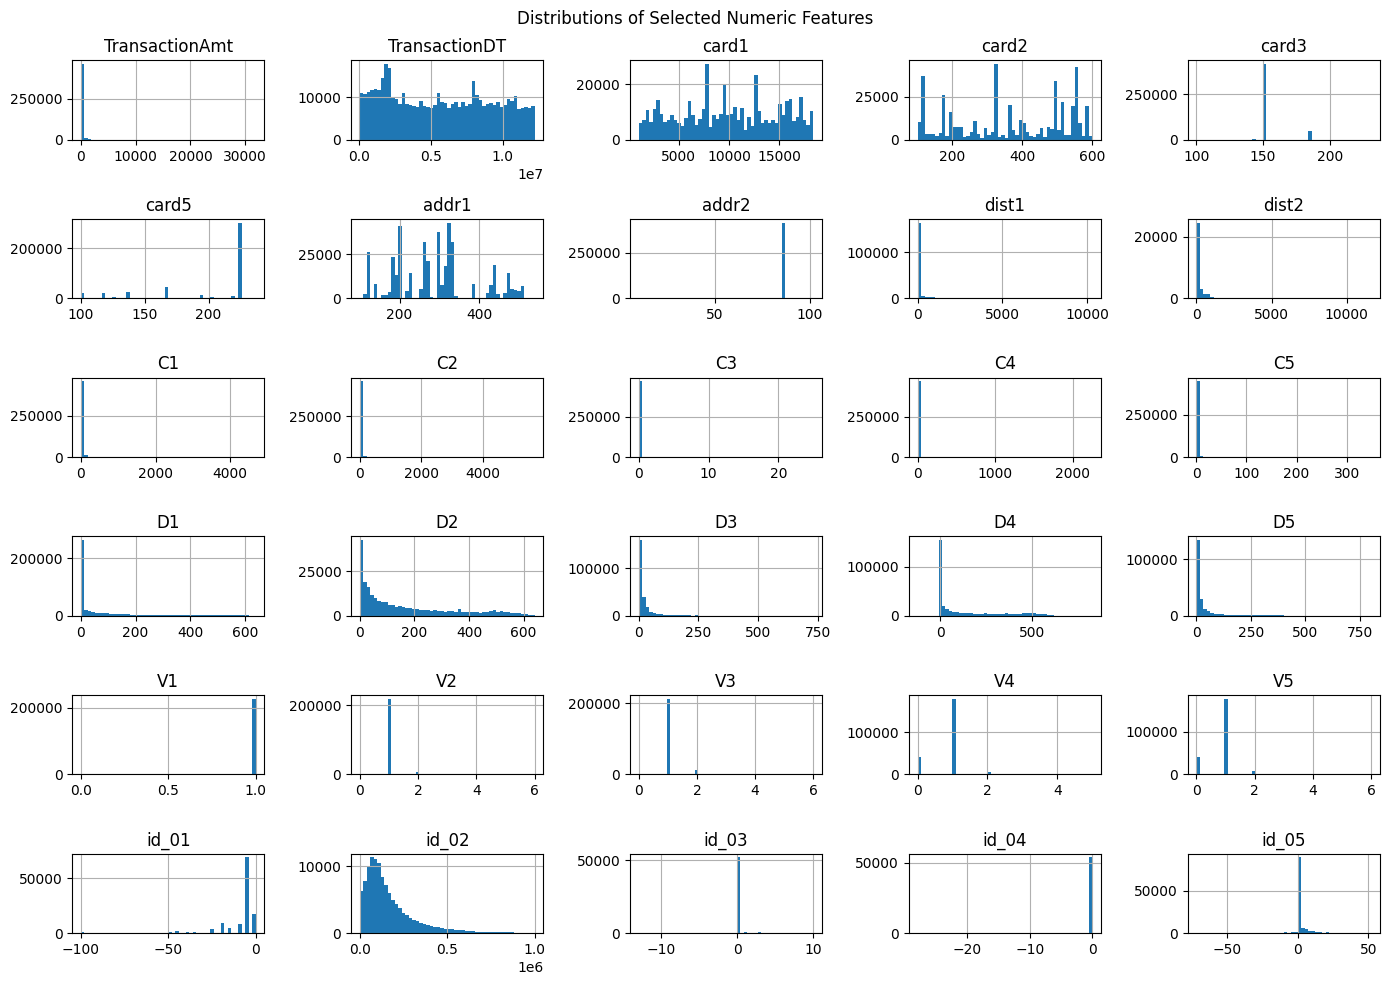

In [24]:
feature_groups = {
    "transaction": ["TransactionAmt", "TransactionDT"],
    "card": [col for col in X_train.columns if col.startswith("card")],
    "addr": [col for col in X_train.columns if col.startswith("addr")],
    "dist": [col for col in X_train.columns if col.startswith("dist")],
    "C": [col for col in X_train.columns if col.startswith("C")],
    "D": [col for col in X_train.columns if col.startswith("D")],
    "V": [col for col in X_train.columns if col.startswith("V")],
    "id_numeric": [
        col for col in X_train.columns
        if col.startswith("id_") and pd.api.types.is_numeric_dtype(X_train[col])
    ]
}

selected_numeric_cols = []

for group_name, cols in feature_groups.items():
    numeric_group_cols = [
        col for col in cols
        if col in X_train.columns and col in numerical_cols
    ]
    selected_numeric_cols.extend(numeric_group_cols[:5]) # select top 4 from each group to avoid overcrowding

selected_numeric_cols = [col for col in selected_numeric_cols if col in X_train.columns]

X_train[selected_numeric_cols].hist(figsize=(14, 10), bins=50)
plt.suptitle("Distributions of Selected Numeric Features")
plt.tight_layout()
plt.show()

<Axes: >

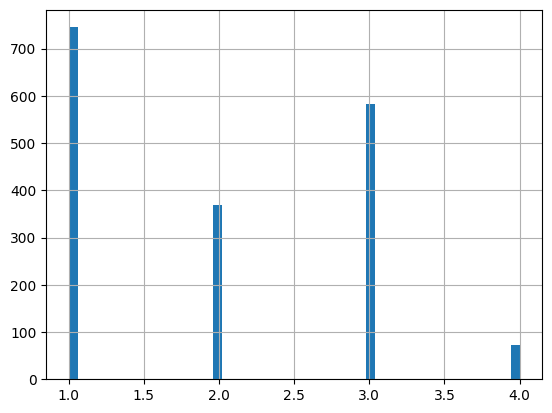

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
X_train["id_03"][(X_train["id_03"] > 0) & (X_train["id_03"] < 5)].hist(bins=50)

In [26]:
Vs = X_train[[col for col in X_train.columns if col.startswith("V")]]

#print(Vs.skew().sort_values(key=abs, ascending=False).head(50))

skew_summary = []

for col in numerical_cols:
    if col == "TransactionID":
        continue

    min_value = X_train[col].min(skipna=True)
    skew_value = X_train[col].skew(skipna=True)

    skew_summary.append({
        "feature": col,
        "min": min_value,
        "skew": skew_value,
        "missing_percentage": X_train[col].isna().mean() * 100,
        "n_unique": X_train[col].nunique(dropna=True)
    })

skew_summary = pd.DataFrame(skew_summary)

log_candidates = (
    skew_summary[
        (skew_summary["min"] >= 0) &
        (skew_summary["skew"].abs() >= 2) &
        (skew_summary["n_unique"] > 10)
    ]
    .sort_values("skew", ascending=False)
)

log_candidates.head(50)

,feature,min,skew,missing_percentage,n_unique
349,V311,0.0,324.662353,0.002540,2664
167,V129,0.0,251.049799,0.020532,1745
347,V309,0.0,235.141979,0.002540,3672
244,V206,0.0,205.774648,75.340578,1502
357,V319,0.0,184.097031,0.002540,3992
307,V269,0.0,176.431207,76.729984,136
304,V266,0.0,174.737430,76.729984,1846
359,V321,0.0,168.042985,0.002540,4588
372,V334,0.0,158.085748,85.178608,126
173,V135,0.0,156.484238,0.020532,3090


In [27]:
log_candidates.shape

(263, 5)

<Axes: >

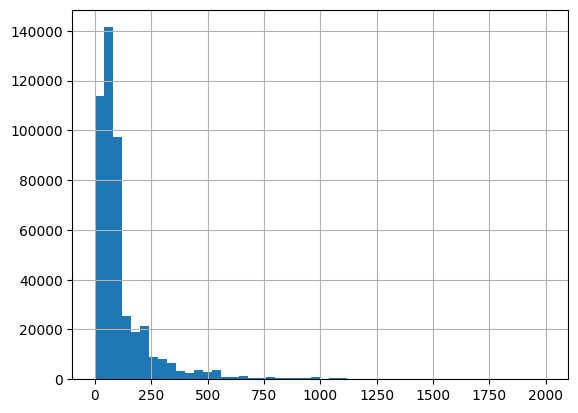

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
X_train["TransactionAmt"][(X_train["TransactionAmt"] >= 0) & (X_train["TransactionAmt"] < 2000)].hist(bins=50)


C:\Users\Myvari\AppData\Local\Temp\ipykernel_24796\2840110844.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.DataFrame({'frac': frac, 'isFraud': y}).groupby(bin_labels)


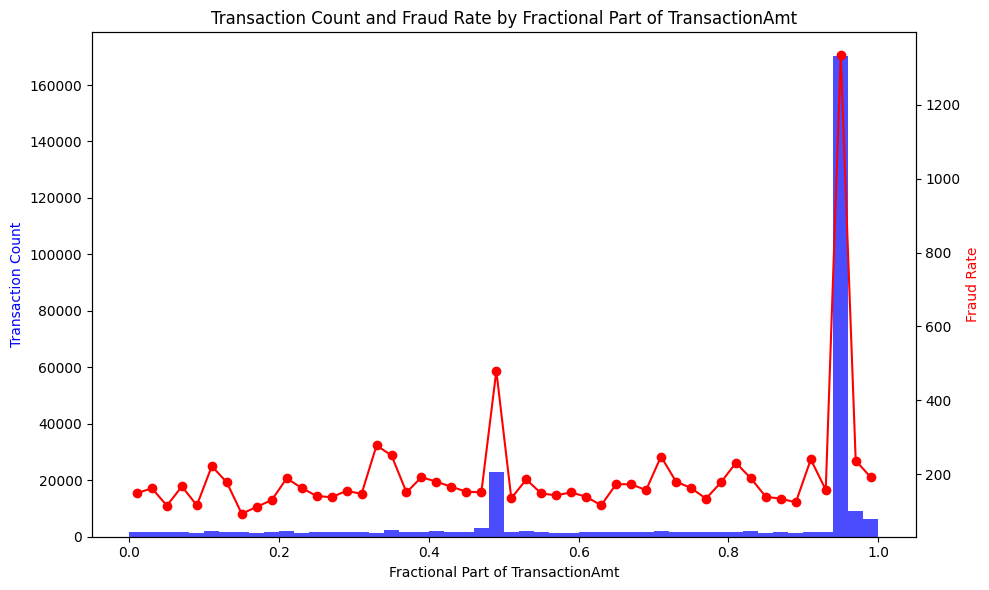

In [100]:
frac = X["TransactionAmt"] - np.floor(X["TransactionAmt"])

bins = np.linspace(0, 1, 51)
bin_centers = (bins[:-1] + bins[1:]) / 2

bin_labels = pd.cut(frac, bins, include_lowest=False) # exclude 0.0 bin to avoid skewing the analysis

grouped = pd.DataFrame({'frac': frac, 'isFraud': y}).groupby(bin_labels)
counts = grouped.size()
fraud_counts = grouped['isFraud'].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(bin_centers, counts, width=0.02, alpha=0.7, label='Transaction Count', color='blue')
ax1.set_xlabel('Fractional Part of TransactionAmt')
ax1.set_ylabel('Transaction Count', color='blue')

ax2 = ax1.twinx()
ax2.plot(bin_centers, fraud_counts, color='red', marker='o', label='Fraud Rate')
ax2.set_ylabel('Fraud Rate', color='red')

plt.title('Transaction Count and Fraud Rate by Fractional Part of TransactionAmt')
plt.tight_layout()
plt.show()

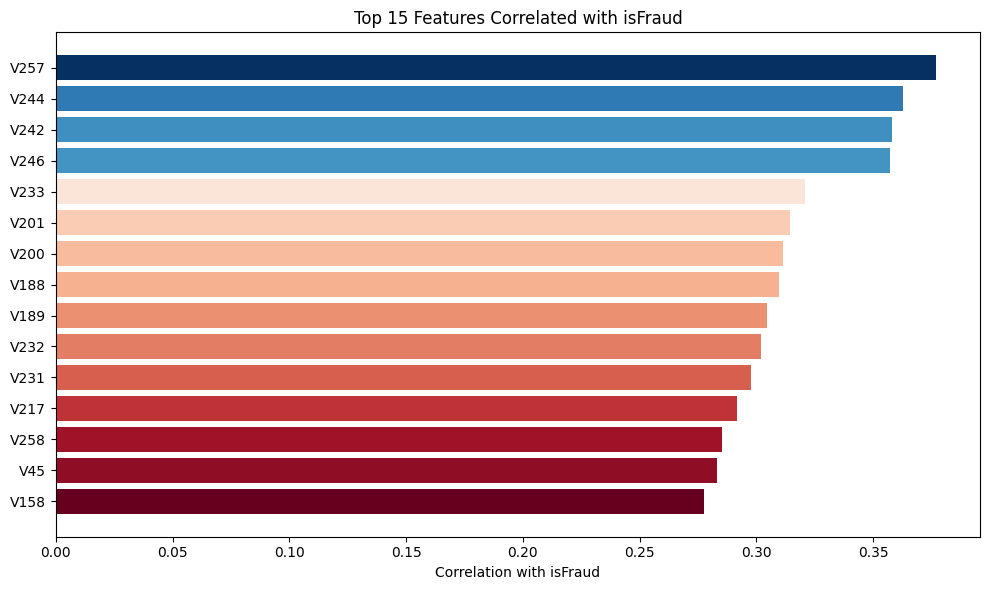

In [101]:
corr_with_target = (
    X_train[numerical_cols_no_id]
    .corrwith(y_train)
    .dropna()
    .sort_values(key=abs, ascending=False)
)

top_corr = corr_with_target.head(15)


plt.figure(figsize=(10, 6))
norm = plt.Normalize(vmin=top_corr.min(), vmax=top_corr.max())
colors = plt.cm.RdBu((top_corr.values - top_corr.min()) / (top_corr.max() - top_corr.min()))

plt.barh(range(len(top_corr))[::-1], top_corr.values, color=colors)
plt.yticks(range(len(top_corr))[::-1], top_corr.index)
plt.xlabel(f'Correlation with {y_train.name}')
plt.title(f'Top 15 Features Correlated with {y_train.name}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

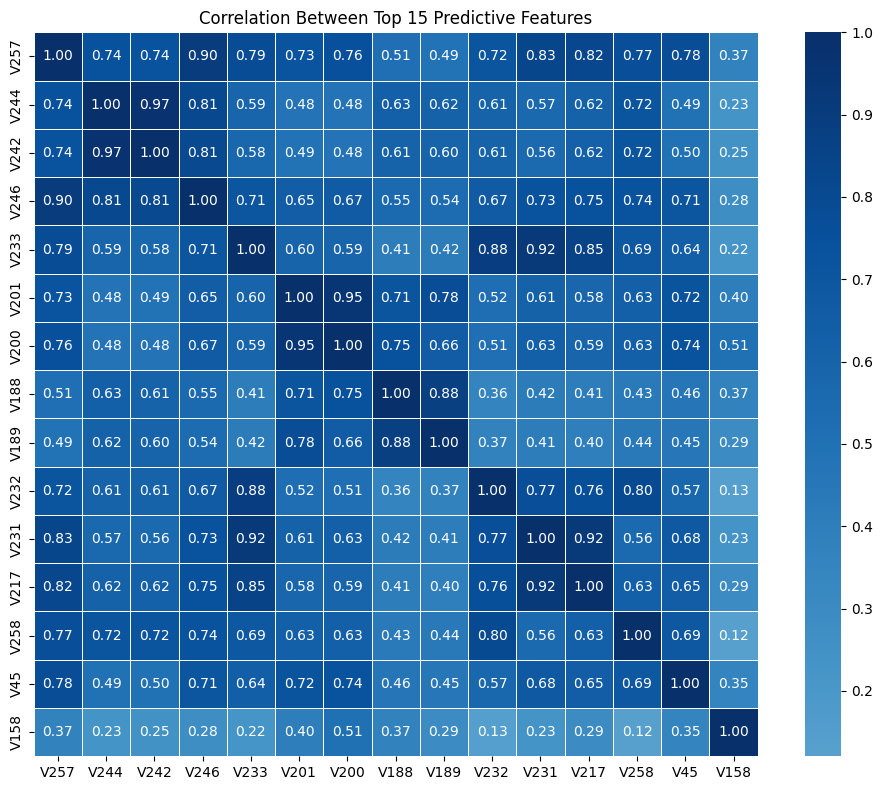

In [102]:
import seaborn as sns

top_15_features = corr_with_target.abs().sort_values(ascending=False).head(15).index
corr_matrix = X_train[top_15_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Between Top 15 Predictive Features')
plt.tight_layout()

In [103]:
categorical_summary = pd.DataFrame({"n_unique": X_train[categorical_cols].nunique(dropna=True)}).sort_values("n_unique", ascending=False)
categorical_summary

,n_unique
DeviceInfo,1639
id_33,212
id_31,110
id_30,72
R_emaildomain,60
P_emaildomain,59
ProductCD,5
card6,4
card4,4
id_34,4


In [104]:
time_eda = pd.DataFrame({
    "TransactionDT": X_train["TransactionDT"],
    "isFraud": y_train
}).sort_values("TransactionDT", ascending=False)

time_eda["transaction_hour"] = (time_eda["TransactionDT"] // 3600) % 24
time_eda["transaction_day"] = time_eda["TransactionDT"] // (3600 * 24)
time_eda["transaction_week"] = time_eda["TransactionDT"] // (3600 * 24 * 7)


weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"] # arbitrary start day since we don't know the actual date of the first transaction

time_eda["transaction_weekday"] = (time_eda["transaction_day"] % 7).map(lambda x: weekday_names[int(x)])
time_eda["transaction_day_of_month"] = (time_eda["transaction_day"] % 31) + 1

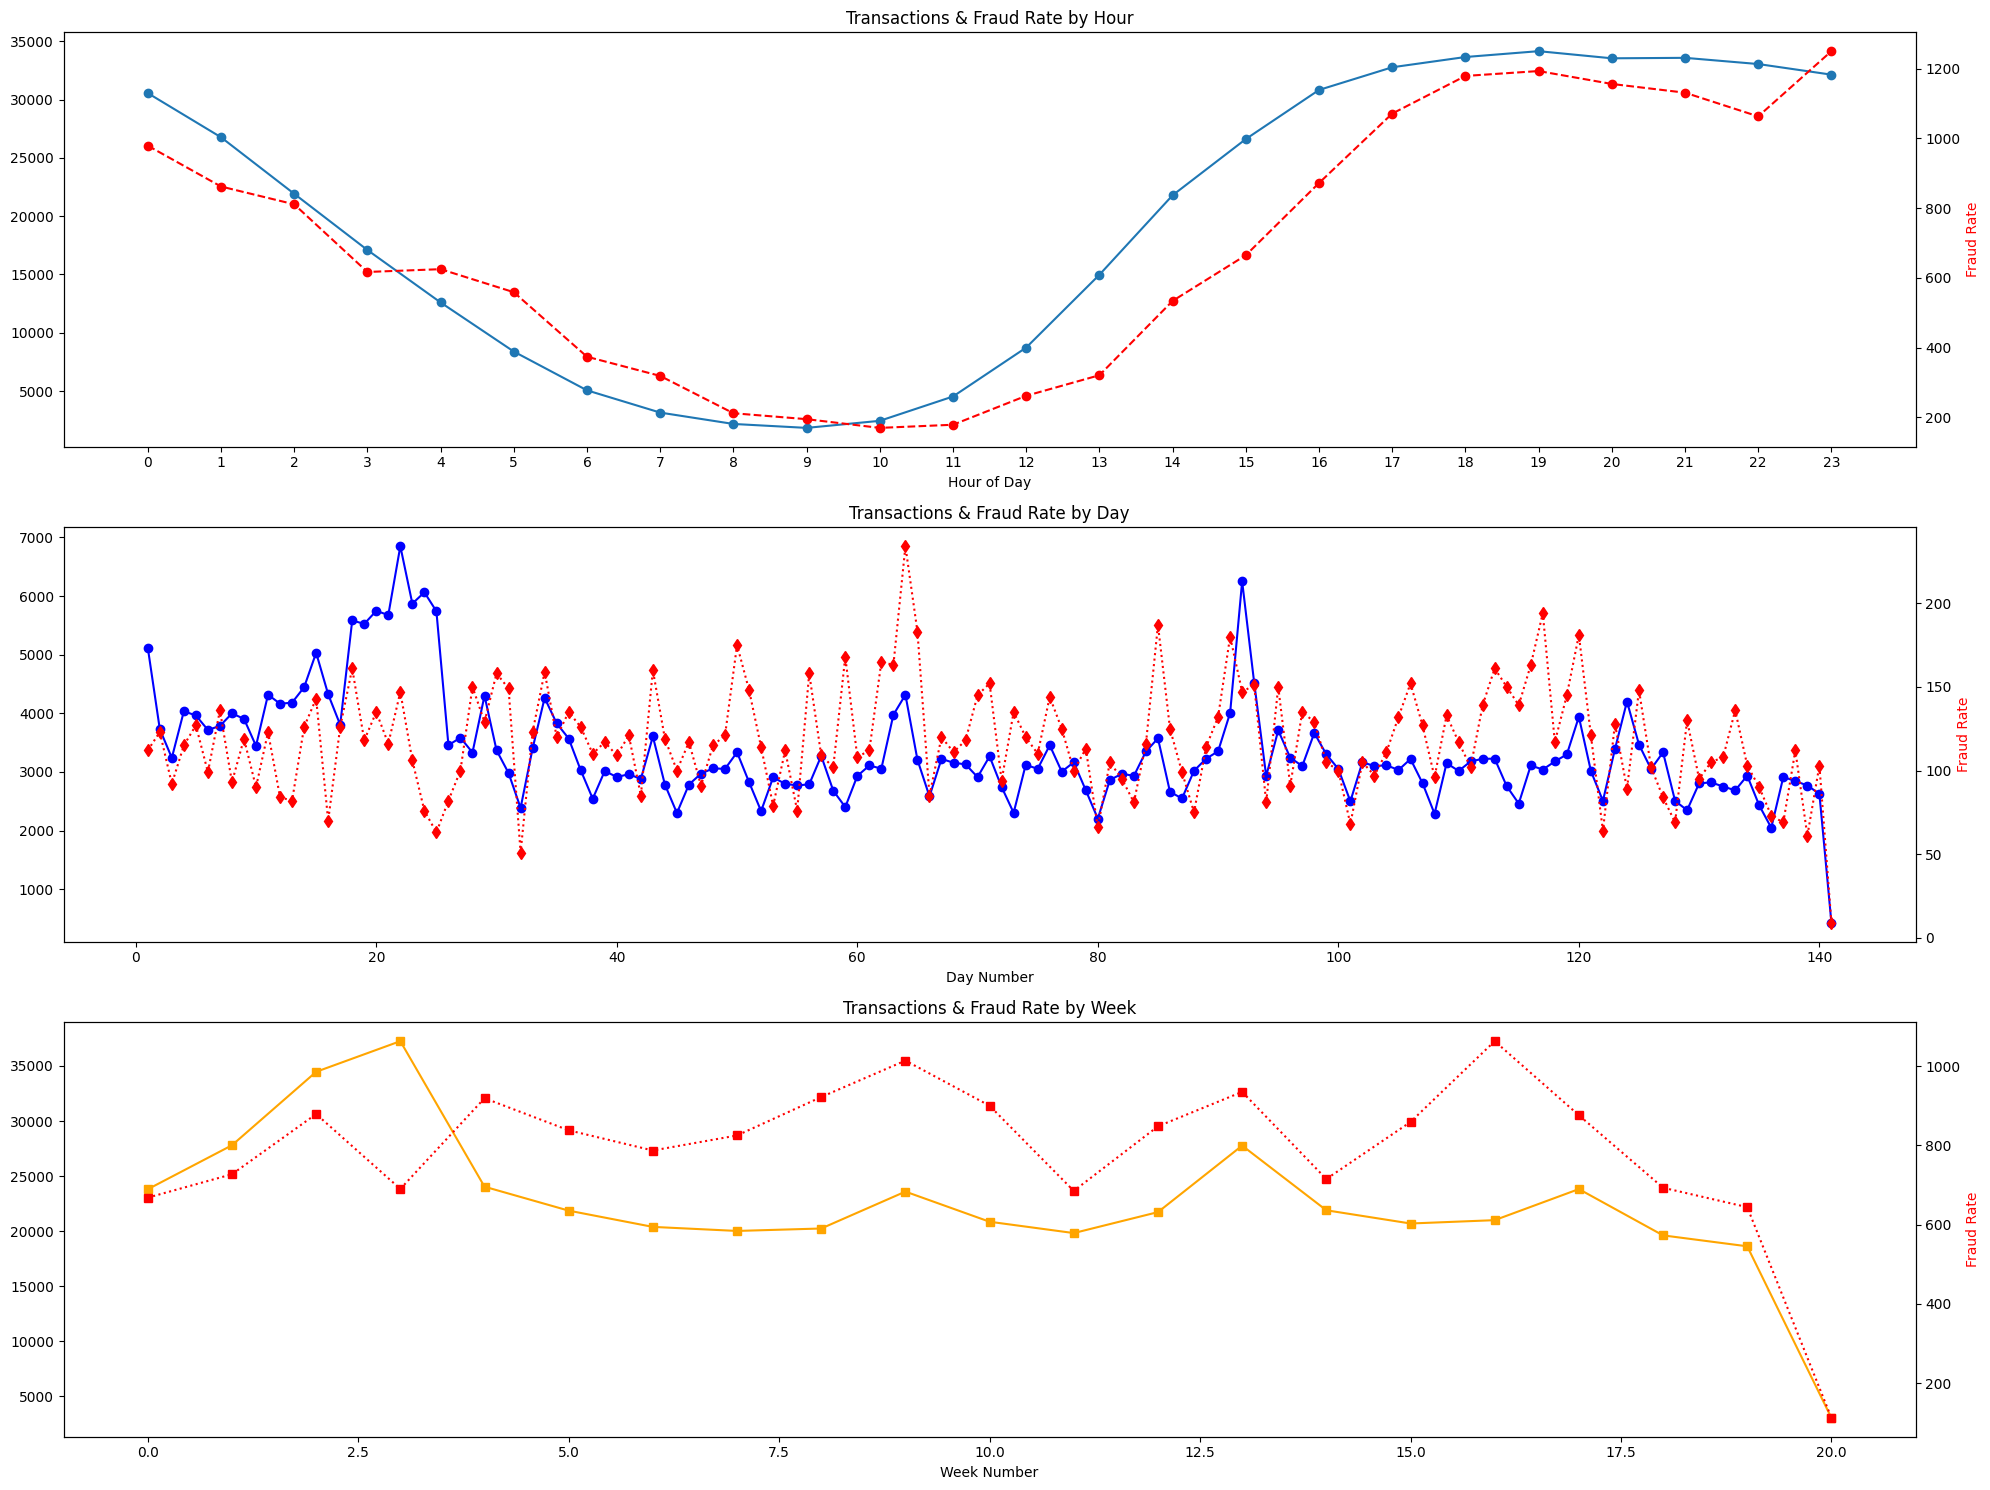

In [105]:
transaction_hour = time_eda.groupby("transaction_hour").size().sort_index()
transaction_day = time_eda.groupby("transaction_day").size().sort_index()
transaction_week = time_eda.groupby("transaction_week").size().sort_index()

fig, axs = plt.subplots(3, 1, figsize=(20, 15))

transaction_hour.plot(kind="line", marker="o", ax=axs[0])
axs[0].set_title("Transaction Count by Hour")
axs[0].set_xticks(range(0, 24))
axs[0].set_xlabel("Hour of Day")

ax0_2 = axs[0].twinx()
fraud_rate_by_hour = time_eda.groupby("transaction_hour")["isFraud"].sum()
fraud_rate_by_hour.plot(kind="line", ax=ax0_2, color="red", linestyle="--", label="Fraud Rate", marker="o")
ax0_2.set_ylabel("Fraud Rate", color="red")
axs[0].set_title("Transactions & Fraud Rate by Hour")

transaction_day.plot(kind="line", ax=axs[1], color='blue', marker="o")
axs[1].set_title("Transaction Count by Day")
axs[1].set_xlabel("Day Number")

ax1_2 = axs[1].twinx()
fraud_rate_by_day = time_eda.groupby("transaction_day")["isFraud"].sum()
fraud_rate_by_day.plot(kind="line", ax=ax1_2, color="red", linestyle=":", label="Fraud Rate", marker="d")
ax1_2.set_ylabel("Fraud Rate", color="red")
axs[1].set_title("Transactions & Fraud Rate by Day")

transaction_week.plot(kind="line", marker="s", ax=axs[2], color='orange')
axs[2].set_title("Transaction Count by Week")
axs[2].set_xlabel("Week Number")

ax2_2 = axs[2].twinx()
fraud_rate_by_week = time_eda.groupby("transaction_week")["isFraud"].sum()
fraud_rate_by_week.plot(kind="line", ax=ax2_2, color="red", linestyle=":", marker="s", label="Fraud Rate")
ax2_2.set_ylabel("Fraud Rate", color="red")
axs[2].set_title("Transactions & Fraud Rate by Week")


plt.tight_layout()
plt.show()

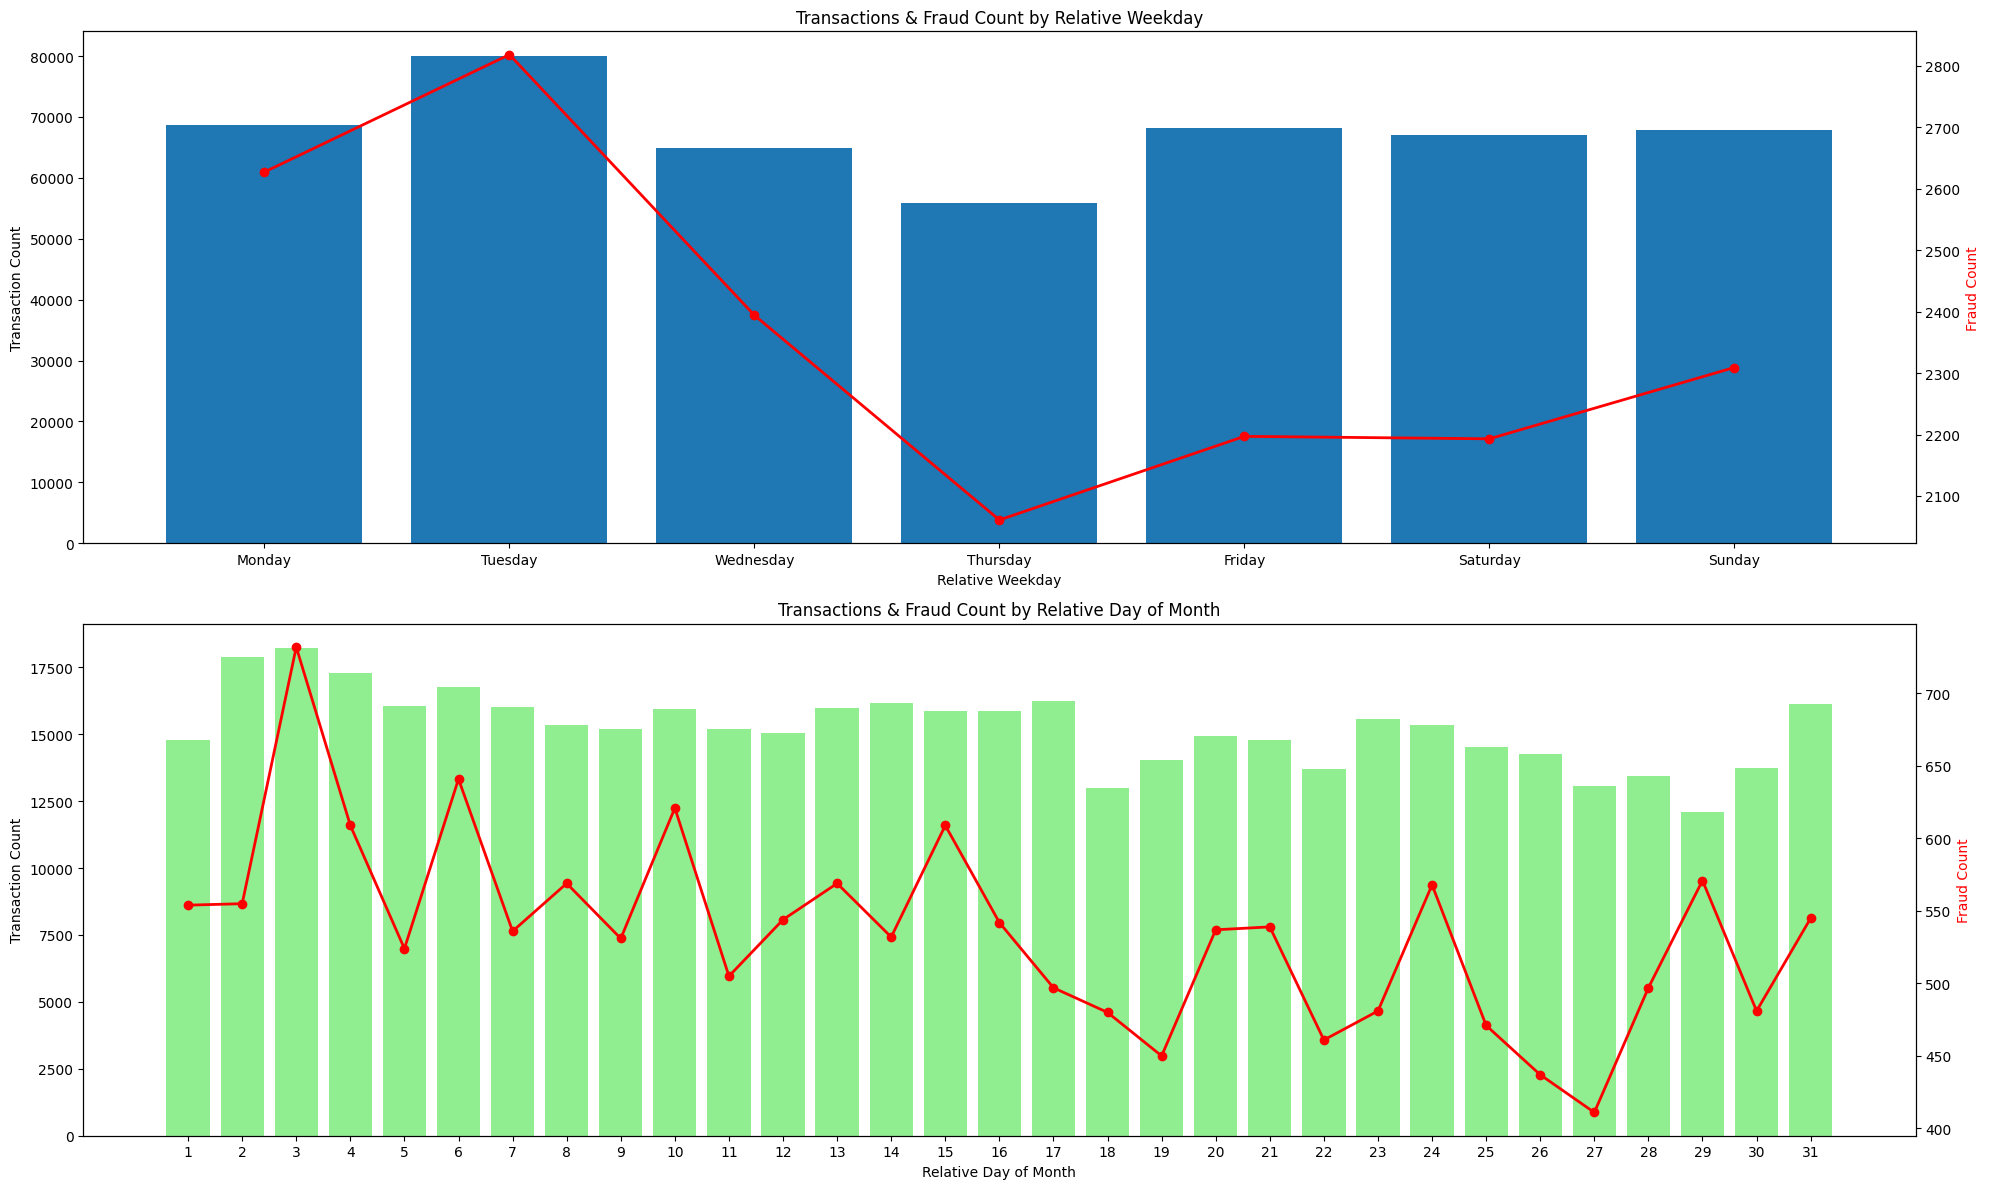

In [106]:
# Weekday
transaction_weekday = time_eda["transaction_weekday"].value_counts().reindex(weekday_names)
fraud_count_weekday = (
    time_eda
    .groupby("transaction_weekday")["isFraud"]
    .sum()
    .reindex(weekday_names)
)

day_index = list(range(1, 32))

transaction_day_of_month = time_eda["transaction_day_of_month"].value_counts().reindex(day_index, fill_value=0)


fraud_count_day_of_month = time_eda.groupby("transaction_day_of_month")["isFraud"].sum().reindex(day_index, fill_value=0)

fig, axs = plt.subplots(2, 1, figsize=(20, 12))

weekday_positions = np.arange(len(weekday_names))

axs[0].bar(weekday_positions, transaction_weekday.values)
axs[0].set_title("Transactions & Fraud Count by Relative Weekday")
axs[0].set_xlabel("Relative Weekday")
axs[0].set_ylabel("Transaction Count")
axs[0].set_xticks(weekday_positions)
axs[0].set_xticklabels(weekday_names, rotation=0)

ax0_2 = axs[0].twinx()
ax0_2.plot(weekday_positions, fraud_count_weekday.values, color="red", marker="o", linewidth=2, label="Fraud Count")
ax0_2.set_ylabel("Fraud Count", color="red")

day_positions = np.arange(len(day_index))

axs[1].bar(day_positions, transaction_day_of_month.values, color="lightgreen")
axs[1].set_title("Transactions & Fraud Count by Relative Day of Month")
axs[1].set_xlabel("Relative Day of Month")
axs[1].set_ylabel("Transaction Count")
axs[1].set_xticks(day_positions)
axs[1].set_xticklabels(day_index, rotation=0)

ax1_2 = axs[1].twinx()
ax1_2.plot(day_positions, fraud_count_day_of_month.values, color="red", marker="o", linewidth=2, label="Fraud Count")
ax1_2.set_ylabel("Fraud Count", color="red")

plt.tight_layout()
plt.show()

`TransactionDT` shows clear time related structure. Transaction volume and raw (more convenient than fractional in this case) fraud count vary across relative hours, days, and weeks. Relative weekday plot also suggests that some weekdays contain more fraudulent transactions than others, while the relative day of month pattern is less stable and may contain more noise. Since `TransactionDT` is a relative timestamp rather than a confirmed calendar date so these derived variables should be interpreted cautiously. In feature engineering, we'll test time features hour, day, week, weekday, and day of month, and evaluate whether they improve validation performance.

In [107]:
df_test_transaction = pd.read_csv(DATA_DIR / "test_transaction.csv")
df_test_identity = pd.read_csv(DATA_DIR / "test_identity.csv")

test_df = pd.merge(df_test_transaction, df_test_identity, on="TransactionID", how="left")

print(f"Test transaction shape: {df_test_transaction.shape}")
print(f"Test identity shape:    {df_test_identity.shape}")
print(f"Merged test shape:      {test_df.shape}")

Test transaction shape: (506691, 393)
Test identity shape:    (141907, 41)
Merged test shape:      (506691, 433)


In [108]:
# test_df.columns = [col.replace('id-', 'id_') if col.startswith('id-') else col for col in test_df.columns]
train_features = set(X_train.columns)
test_features = set(test_df.columns)

print(f"Columns in train but not test: {len(train_features - test_features)}", train_features - test_features)
print(f"Columns in test but not train: {len(test_features - train_features)}", test_features - train_features)

# The test set has 38 id columns different from the training set, coming from the naming inconsistency of id_ vs id- in the two datasets. fixed when loading.

Columns in train but not test: 38 {'id_12', 'id_36', 'id_14', 'id_25', 'id_30', 'id_06', 'id_24', 'id_11', 'id_31', 'id_29', 'id_27', 'id_04', 'id_09', 'id_28', 'id_05', 'id_03', 'id_02', 'id_33', 'id_26', 'id_34', 'id_08', 'id_17', 'id_10', 'id_07', 'id_22', 'id_35', 'id_21', 'id_19', 'id_18', 'id_20', 'id_38', 'id_13', 'id_32', 'id_16', 'id_23', 'id_37', 'id_15', 'id_01'}
Columns in test but not train: 38 {'id-26', 'id-01', 'id-23', 'id-05', 'id-02', 'id-31', 'id-33', 'id-03', 'id-21', 'id-12', 'id-25', 'id-16', 'id-22', 'id-30', 'id-14', 'id-27', 'id-38', 'id-28', 'id-37', 'id-06', 'id-07', 'id-04', 'id-17', 'id-20', 'id-34', 'id-32', 'id-36', 'id-10', 'id-29', 'id-13', 'id-19', 'id-24', 'id-09', 'id-15', 'id-35', 'id-11', 'id-18', 'id-08'}


In [109]:
time_range_comparison = pd.DataFrame({
    "train": [
        X_train["TransactionDT"].min(),
        X_train["TransactionDT"].max()
    ],
    "test": [
        test_df["TransactionDT"].min(),
        test_df["TransactionDT"].max()
    ]
}, index=["min_TransactionDT", "max_TransactionDT"])

time_range_comparison

,train,test
min_TransactionDT,86400,18403224
max_TransactionDT,12192842,34214345


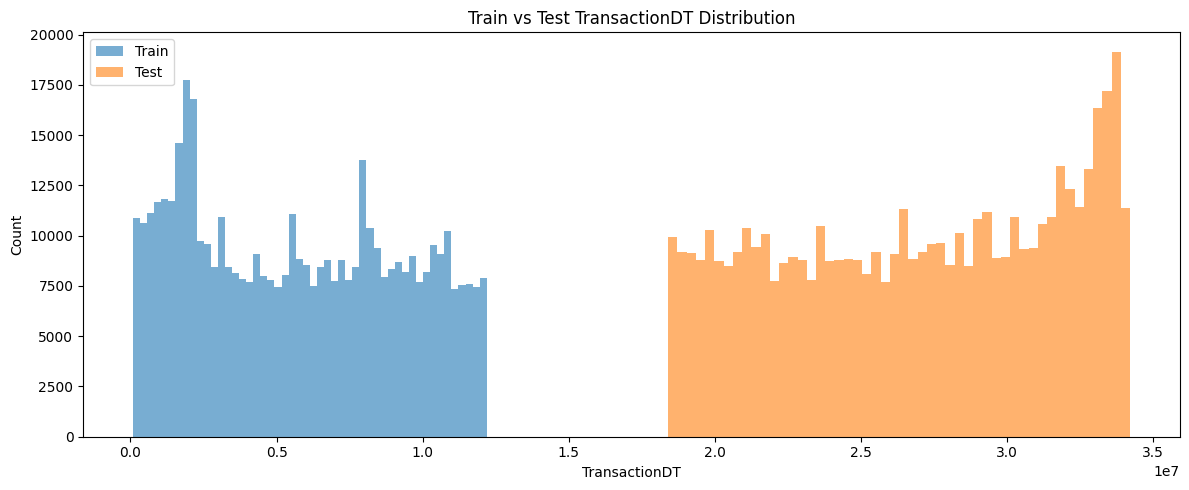

In [110]:
plt.figure(figsize=(12, 5))
plt.hist(X_train["TransactionDT"], bins=50, alpha=0.6, label="Train")
plt.hist(test_df["TransactionDT"], bins=50, alpha=0.6, label="Test")
plt.title("Train vs Test TransactionDT Distribution")
plt.xlabel("TransactionDT")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

test set comes from a later time period than the training set. We'll use time-aware split methods in both inital and k-fold splits for better validation.

# Data Cleaning

In [111]:
from sklearn.base import BaseEstimator, TransformerMixin

class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        drop_transaction_id=True,
        missing_threshold=None,
        drop_constant=True,
        drop_high_cardinality_cols=None
    ):
        self.drop_transaction_id = drop_transaction_id
        self.missing_threshold = missing_threshold
        self.drop_constant = drop_constant
        self.drop_high_cardinality_cols = drop_high_cardinality_cols

    def fit(self, X, y=None):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        self.columns_to_drop_ = []

        if self.drop_transaction_id and "TransactionID" in X.columns:
            self.columns_to_drop_.append("TransactionID")

        drop_high_cardinality_cols = (
            self.drop_high_cardinality_cols
            if self.drop_high_cardinality_cols is not None
            else []
        )

        # drop high cardinality columns if selected
        for col in drop_high_cardinality_cols:
            if col in X.columns:
                self.columns_to_drop_.append(col)

        # drop columns if missingness above threshold
        if self.missing_threshold is not None:
            missing_rates = X.isna().mean()
            high_missing_cols = missing_rates[missing_rates > self.missing_threshold].index.tolist()
            self.columns_to_drop_.extend(high_missing_cols)

        # drop constant columns
        if self.drop_constant:
            constant_cols = [
                col for col in X.columns
                if X[col].nunique(dropna=False) <= 1
            ]
            self.columns_to_drop_.extend(constant_cols)

        self.columns_to_drop_ = sorted(set(self.columns_to_drop_))

        return self


    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        X = X.replace([np.inf, -np.inf], np.nan) # handle infinite values if any

        X = X.drop(columns=self.columns_to_drop_, errors="ignore")

        return X

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
import numpy as np

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")), # "missing" since missingness itself carries a signal
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# cat_pipeline_dense = Pipeline([
#     ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
#     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # dense output for custom selectors (correlation analysis and feature selection)
# ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ]
)

# preprocessor_dense = ColumnTransformer(
#     transformers=[
#         ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
#         ("cat", cat_pipeline_dense, make_column_selector(dtype_include=object)),
#     ],
#     verbose_feature_names_out=False
# )

# preprocessor_dense.set_output(transform="pandas")

# Feature Engineering

In [125]:

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        add_identity_feature=True,
        add_amount_features=True,
        add_time_features=True,
        add_email_groups=True,
        add_cd_log_features=False,
        add_skewed_log_features=False,
        skew_threshold=2.0
    ):
        self.add_identity_feature = add_identity_feature
        self.add_amount_features = add_amount_features
        self.add_time_features = add_time_features
        self.add_email_groups = add_email_groups
        self.add_cd_log_features = add_cd_log_features
        self.add_skewed_log_features = add_skewed_log_features
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        self.skewed_log_cols_ = []

        if self.add_skewed_log_features:
            numeric_cols = X.select_dtypes(include=["number"]).columns

            allowed_prefixes = ("V", "C", "D", "dist") # exclude ids for now
            
            for col in numeric_cols:
                if col in ["TransactionID", "TransactionDT"]:
                    continue

                is_allowed_group = (
                    col == "TransactionAmt"
                    or col.startswith(allowed_prefixes)
                )

                if not is_allowed_group:
                    continue

                min_value = X[col].min(skipna=True)
                skew_value = X[col].skew(skipna=True)
                n_unique = X[col].nunique(dropna=True)

                if (
                    pd.notna(min_value)
                    and min_value >= 0
                    and pd.notna(skew_value)
                    and abs(skew_value) >= self.skew_threshold
                    and n_unique > 10
                ):
                    self.skewed_log_cols_.append(col)

        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        if self.add_identity_feature:
            if "id_01" in X.columns: # defensive check since some versions of the dataset have inconsistent id column naming
                X["has_identity"] = X["id_01"].notna().astype(int)
            else:
                X["has_identity"] = 0

        # transaction amount features
        if self.add_amount_features and "TransactionAmt" in X.columns:
            X["TransactionAmt_log"] = np.log1p(X["TransactionAmt"])
            X["TransactionAmt_decimal"] = (X["TransactionAmt"] - np.floor(X["TransactionAmt"]))

        if self.add_time_features and "TransactionDT" in X.columns:
            seconds_in_hour = 3600
            seconds_in_day = seconds_in_hour * 24

            transaction_hour = (X["TransactionDT"] // seconds_in_hour) % 24
            transaction_day = X["TransactionDT"] // seconds_in_day
            transaction_week = transaction_day // 7

            X["transaction_day"] = transaction_day
            X["transaction_week"] = transaction_week

            # cyclic encoding for time features (better reflecting of their nature)
            day_of_month = transaction_day % 31
            X["transaction_day_of_month_sin"] = np.sin(2 * np.pi * day_of_month / 31)
            X["transaction_day_of_month_cos"] = np.cos(2 * np.pi * day_of_month / 31)

            weekday = transaction_day % 7
            X["transaction_weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
            X["transaction_weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

            X["transaction_hour_sin"] = np.sin(2 * np.pi * transaction_hour / 24)
            X["transaction_hour_cos"] = np.cos(2 * np.pi * transaction_hour / 24)


        if self.add_email_groups:
            for col in ["P_emaildomain", "R_emaildomain"]:
                if col in X.columns:
                    X[f"{col}_group"] = X[col].apply(self._group_email_domain)



        if self.add_cd_log_features:
            cd_cols = [
                col for col in X.columns
                if (col.startswith("C") or col.startswith("D"))
                and pd.api.types.is_numeric_dtype(X[col])
            ]

            for col in cd_cols:
                # only apply log1p safely to columns with no negative values
                min_value = X[col].min(skipna=True)

                if pd.notna(min_value) and min_value >= 0:
                    X[f"{col}_log"] = np.log1p(X[col])

        if self.add_skewed_log_features:
            for col in self.skewed_log_cols_:
                if col in X.columns:
                    X[f"{col}_log"] = np.log1p(X[col])

        X = X.replace([np.inf, -np.inf], np.nan)

        return X
    
    def _group_email_domain(self, value):
        if pd.isna(value):
            return "missing"

        value = str(value).lower()

        if "gmail" in value:
            return "gmail"
        elif "yahoo" in value:
            return "yahoo"
        elif value in ["hotmail.com", "outlook.com", "live.com", "msn.com"]:
            return "microsoft"
        elif "icloud" in value or "me.com" in value or "mac.com" in value:
            return "apple"
        elif "anonymous" in value:
            return "anonymous"
        elif "aol" in value:
            return "aol"
        else:
            return "other"
    
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

# Feature Selection

In [126]:
class CorrelationReducer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95, verbose=True):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y=None):
        X_df = X.copy()
        self.feature_names_ = X_df.columns.tolist()

        corr_matrix = X_df.corr().abs()

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        upper = corr_matrix.where(mask)

        to_remove = set()

        for col in upper.columns:
            correlated_features = upper[upper[col] > self.threshold].index.tolist()

            for other in correlated_features:
                # mean correlation with other features (since some pairs are missing)
                col_score = corr_matrix[col].mean()
                other_score = corr_matrix[other].mean()

                if col_score > other_score:
                    to_remove.add(col)
                else:
                    to_remove.add(other)

        self.removed_features_ = sorted(to_remove)
        self.kept_features_ = [
            feature for feature in self.feature_names_
            if feature not in self.removed_features_
        ]

        if self.verbose:
            print(f"[Correlation] Removed {len(self.removed_features_)} features: {self.removed_features_}")
            print(f"[Correlation] Kept {len(self.kept_features_)} features: {self.kept_features_}")

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.feature_names_

        return X_df[self.kept_features_]

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [127]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

class FeatureSelectorRFE(BaseEstimator, TransformerMixin):
    def __init__(self, n_features=100, estimator=None, verbose=True):
        self.n_features = n_features
        self.estimator = estimator
        self.verbose = verbose

    def fit(self, X, y):
        X_df = X.copy()
        self.input_features_ = X_df.columns.tolist()

        if self.estimator is None:
            estimator = LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced")
        else:
            estimator = self.estimator

        self.selector_ = RFE(estimator=estimator, n_features_to_select=self.n_features, step=0.1)

        self.selector_.fit(X_df, y)

        mask = self.selector_.support_
        self.selected_features_ = list(pd.Index(self.input_features_)[mask])

        if self.verbose:
            print(f"[RFE] Selected {len(self.selected_features_)} features: {self.selected_features_}")

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.input_features_

        return X_df[self.selected_features_]

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [ ]:
class InformationValueSelector(BaseEstimator, TransformerMixin): # before OHE to avoid dimensionality explosion and sparse matrix issues
    def __init__(
        self,
        threshold=0.02,
        n_bins=10, # for numeric features with many unique values
        max_unique_for_categorical=100,
        min_bin_size=50,
        verbose=True
    ):
        self.threshold = threshold
        self.n_bins = n_bins
        self.max_unique_for_categorical = max_unique_for_categorical
        self.min_bin_size = min_bin_size
        self.verbose = verbose

    def fit(self, X, y):
        X_df = X.copy()
        y_series = pd.Series(y).reset_index(drop=True)
        X_df = X_df.reset_index(drop=True)

        self.feature_names_ = X_df.columns.tolist()
        self.iv_scores_ = {}

        for col in self.feature_names_:
            try:
                iv = self._calculate_feature_iv(X_df[col], y_series)
            except Exception:
                iv = 0.0

            self.iv_scores_[col] = iv

        self.iv_scores_df_ = (
            pd.DataFrame({
                "feature": list(self.iv_scores_.keys()),
                "iv": list(self.iv_scores_.values())
            })
            .sort_values("iv", ascending=False)
            .reset_index(drop=True)
        )

        self.selected_features_ = self.iv_scores_df_.loc[self.iv_scores_df_["iv"] >= self.threshold, "feature"].tolist()

        if len(self.selected_features_) == 0:
            best_feature = self.iv_scores_df_.iloc[0]["feature"] # select the best feature, avoid empty feature set
            self.selected_features_ = [best_feature]

        if self.verbose:
            print(f"[IV] Selected {len(self.selected_features_)} / {len(self.feature_names_)} features")
            print("[IV] Top features:")
            print(self.iv_scores_df_.head(20))

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.feature_names_

        return X_df[self.selected_features_]

    def _calculate_feature_iv(self, feature, y):
        prepared_feature = self._prepare_feature(feature) # convert to categorical with appropriate binning

        df = pd.DataFrame({"feature": prepared_feature, "target": y})

        grouped = df.groupby("feature", dropna=False)["target"].agg(events="sum", total="count")

        grouped["non_events"] = grouped["total"] - grouped["events"]

        # -tiny bins to reduce instability
        grouped = grouped[grouped["total"] >= self.min_bin_size]

        if grouped.shape[0] <= 1:
            return 0.0

        total_events = grouped["events"].sum()
        total_non_events = grouped["non_events"].sum()

        if total_events == 0 or total_non_events == 0:
            return 0.0

        eps = 0.5 # smoothing factor

        grouped["event_dist"] = (grouped["events"] + eps) / (total_events + eps * grouped.shape[0])
        grouped["non_event_dist"] = (grouped["non_events"] + eps) / (total_non_events + eps * grouped.shape[0])

        grouped["woe"] = np.log(grouped["event_dist"] / grouped["non_event_dist"])
        grouped["iv_component"] = (grouped["event_dist"] - grouped["non_event_dist"]) * grouped["woe"]

        return grouped["iv_component"].sum()

    def _prepare_feature(self, feature):
        feature = feature.copy()

        if pd.api.types.is_numeric_dtype(feature):
            unique_count = feature.nunique(dropna=True)

            if unique_count > self.n_bins:
                try:
                    return pd.qcut(feature, q=self.n_bins, duplicates="drop").astype(str).fillna("missing")
                except Exception:
                    return feature.fillna(-999999)
            else:
                return feature.fillna(-999999)

        else:
            feature = feature.astype("object").where(feature.notna(), "missing")
            unique_count = feature.nunique(dropna=True)

            if unique_count > self.max_unique_for_categorical:
                top_values = feature.value_counts().head(self.max_unique_for_categorical).index
                feature = feature.where(feature.isin(top_values), "rare") # rare category for infrequent

            return feature.astype(str)

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

# Full Pipline

In [ ]:
preprocessing_pipeline = Pipeline([
    ("cleaner", DataCleaner(drop_high_cardinality_cols=["DeviceInfo"])),
    ("feature_engineer", FeatureEngineer()),
    ("iv_selector", InformationValueSelector(verbose=False)),
    ("preprocessor", preprocessor),
])

In [144]:
import mlflow
import skops.io as sio
import joblib

mlflow.set_experiment("ieee_fraud_preprocessing")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="LogisticRegression_Preprocessing_IV"):

    mlflow.log_param("cleaner_drop_transaction_id", True)
    mlflow.log_param("cleaner_missing_threshold", None)
    mlflow.log_param("cleaner_drop_constant", True)

    mlflow.log_param("add_identity_feature", True)
    mlflow.log_param("add_amount_features", True)
    mlflow.log_param("add_time_features", True)
    mlflow.log_param("add_email_groups", True)
    mlflow.log_param("add_cd_log_features", False)
    mlflow.log_param("add_skewed_log_features", False)
    mlflow.log_param("drop_high_cardinality_cols", ["DeviceInfo"])

    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("cat_impute_strategy", "constant_missing")
    mlflow.log_param("categorical_encoder", "OneHotEncoder")
    mlflow.log_param("ohe_handle_unknown", "ignore")
    mlflow.log_param("ohe_sparse_output", True)
    mlflow.log_param("scaler", "StandardScaler")

    mlflow.log_param("iv_threshold", 0.02)
    mlflow.log_param("iv_n_bins", 10)
    mlflow.log_param("iv_max_unique_for_categorical", 100)
    mlflow.log_param("iv_min_bin_size", 50)

    preprocessing_pipeline.fit(X_train, y_train)

    joblib.dump(preprocessing_pipeline, "logreg_preprocessing_pipeline_iv.joblib")
    mlflow.log_artifact("logreg_preprocessing_pipeline_iv.joblib")

    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")

Preprocessing run id: ec9c4177425a4690bdfae599d5359618
🏃 View run LogisticRegression_Preprocessing_IV at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/ec9c4177425a4690bdfae599d5359618
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [145]:
X_train_transformed = preprocessing_pipeline.transform(X_train)
X_valid_transformed = preprocessing_pipeline.transform(X_test)

print(X_train_transformed.shape)
print(X_valid_transformed.shape)

(472432, 937)
(118108, 937)


In [ ]:
# preprocessing_pipeline_corr_rfe = Pipeline([
#     ("cleaner", DataCleaner(drop_high_cardinality_cols=["DeviceInfo"])),  # optional, helps control OHE size
#     ("feature_engineer", FeatureEngineer()),
#     ("preprocessor", preprocessor_dense),
#     ("corr_reduce", CorrelationReducer()),
#     ("rfe", FeatureSelectorRFE()),
# ])

In [ ]:
# with mlflow.start_run(run_name="LogisticRegression_Preprocessing_Corr_RFE"):

#     mlflow.log_param("cleaner_drop_transaction_id", True)
#     mlflow.log_param("cleaner_missing_threshold", None)
#     mlflow.log_param("cleaner_drop_constant", True)
#     mlflow.log_param("cleaner_drop_columns", "DeviceInfo")

#     mlflow.log_param("add_identity_feature", True)
#     mlflow.log_param("add_amount_features", True)
#     mlflow.log_param("add_time_features", True)
#     mlflow.log_param("add_email_groups", True)
#     mlflow.log_param("add_cd_log_features", False)
#     mlflow.log_param("add_skewed_log_features", False)

#     mlflow.log_param("num_impute_strategy", "median")
#     mlflow.log_param("cat_impute_strategy", "constant_missing")
#     mlflow.log_param("categorical_encoder", "OneHotEncoder")
#     mlflow.log_param("ohe_sparse_output", False)
#     mlflow.log_param("scaler", "StandardScaler")

#     mlflow.log_param("corr_threshold", 0.8)
#     mlflow.log_param("rfe_n_features", 100)
#     mlflow.log_param("rfe_estimator", "LogisticRegression")

#     preprocessing_pipeline_corr_rfe.fit(X_train, y_train)

#     sio.dump(preprocessing_pipeline_corr_rfe, "logreg_preprocessing_pipeline_corr_rfe.skops")
#     mlflow.log_artifact("logreg_preprocessing_pipeline_corr_rfe.skops")

#     preprocessing_corr_rfe_run_id = mlflow.active_run().info.run_id
#     print(f"Preprocessing run id: {preprocessing_corr_rfe_run_id}")

# Logistic Regression with IV-selected features

In [ ]:
# from sklearn.base import clone
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import TimeSeriesSplit, cross_validate
# from sklearn.metrics import (
#     accuracy_score,
#     f1_score,
#     roc_auc_score,
#     precision_score,
#     recall_score,
#     average_precision_score,
#     log_loss
# )

# mlflow.set_experiment("linear_regression_v1")

# cv = TimeSeriesSplit(n_splits=3) # we sorted the data by time already

# param_grid = [
#     # L2 baseline
#     {"C": 0.1,  "solver": "lbfgs", "penalty": "l2", "class_weight": None},
#     {"C": 1.0,  "solver": "lbfgs", "penalty": "l2", "class_weight": None},

#     # L2 with class balancing
#     {"C": 0.1,  "solver": "lbfgs", "penalty": "l2", "class_weight": "balanced"},
#     {"C": 1.0,  "solver": "lbfgs", "penalty": "l2", "class_weight": "balanced"},

#     # L1 embedded selection
#     {"C": 0.01, "solver": "liblinear", "penalty": "l1", "class_weight": "balanced"},
#     {"C": 0.1,  "solver": "liblinear", "penalty": "l1", "class_weight": "balanced"},
#     {"C": 1.0,  "solver": "liblinear", "penalty": "l1", "class_weight": "balanced"},

#     # ElasticNet
#     {"C": 0.1, "solver": "saga", "penalty": "elasticnet", "l1_ratio": 0.5, "class_weight": "balanced"},
# ]

# scoring = {
#     "roc_auc": "roc_auc",
#     "average_precision": "average_precision",
#     "neg_log_loss": "neg_log_loss",
#     "accuracy": "accuracy",
#     "f1": "f1",
#     "precision": "precision",
#     "recall": "recall"
# }

# results = []

# for params in param_grid:
#     run_name = (
#         f"LogReg_{params['penalty']}_"
#         f"C{params['C']}_"
#         f"{params['solver']}_"
#         f"{'balanced' if params.get('class_weight') == 'balanced' else 'unbalanced'}"
#     )

#     with mlflow.start_run(run_name=run_name):
#         mlflow.set_tag("model_type", "LogisticRegression")
#         mlflow.set_tag("validation_type", "TimeSeriesSplit")
#         mlflow.set_tag("preprocessing_type", "IV_Preprocessing")
#         mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)

#         mlflow.log_params(params)
#         mlflow.log_param("cv_n_splits", 3)
#         mlflow.log_param("main_metric", "roc_auc")

#         model = LogisticRegression(
#             **params,
#             max_iter=1000,
#             random_state=42
#         )

#         # # create a pipeline that includes preprocessing and the model for proper cross-validation without !data leakage!
#         # full_pipeline = Pipeline([
#         #     ("preprocessing", clone(preprocessing_pipeline)),
#         #     ("model", model)
#         # ])

#         cv_results = cross_validate(
#             #full_pipeline,
#             model,
#             X_train_transformed,
#             y_train,
#             cv=cv,
#             scoring=scoring,
#             return_train_score=True,
#             n_jobs=-1,
#             error_score="raise"
#         )

#         train_roc_auc = cv_results["train_roc_auc"].mean()
#         val_roc_auc = cv_results["test_roc_auc"].mean()

#         train_avg_precision = cv_results["train_average_precision"].mean()
#         val_avg_precision = cv_results["test_average_precision"].mean()

#         train_log_loss = -cv_results["train_neg_log_loss"].mean()
#         val_log_loss = -cv_results["test_neg_log_loss"].mean()

#         mlflow.log_metric("cv_train_roc_auc", train_roc_auc)
#         mlflow.log_metric("cv_val_roc_auc", val_roc_auc)
#         mlflow.log_metric("cv_train_average_precision", train_avg_precision)
#         mlflow.log_metric("cv_val_average_precision", val_avg_precision)
#         mlflow.log_metric("cv_train_log_loss", train_log_loss)
#         mlflow.log_metric("cv_val_log_loss", val_log_loss)

#         mlflow.log_metric("cv_val_accuracy", cv_results["test_accuracy"].mean())
#         mlflow.log_metric("cv_val_f1", cv_results["test_f1"].mean())
#         mlflow.log_metric("cv_val_precision", cv_results["test_precision"].mean())
#         mlflow.log_metric("cv_val_recall", cv_results["test_recall"].mean())

#         mlflow.log_metric("roc_auc_gap", train_roc_auc - val_roc_auc)
#         mlflow.log_metric("log_loss_gap", val_log_loss - train_log_loss)

#         # final holdout validation
#         model.fit(X_train_transformed, y_train)

#         valid_preds = model.predict(X_valid_transformed)
#         valid_proba = model.predict_proba(X_valid_transformed)[:, 1]

#         holdout_roc_auc = roc_auc_score(y_test, valid_proba)
#         holdout_avg_precision = average_precision_score(y_test, valid_proba)
#         holdout_log_loss = log_loss(y_test, valid_proba)

#         mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
#         mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
#         mlflow.log_metric("holdout_log_loss", holdout_log_loss)
#         mlflow.log_metric("holdout_accuracy", accuracy_score(y_test, valid_preds))
#         mlflow.log_metric("holdout_f1", f1_score(y_test, valid_preds, zero_division=0))
#         mlflow.log_metric("holdout_precision", precision_score(y_test, valid_preds, zero_division=0))
#         mlflow.log_metric("holdout_recall", recall_score(y_test, valid_preds, zero_division=0))

#         model_path = f"{run_name}.joblib"
#         joblib.dump(model, model_path)
#         mlflow.log_artifact(model_path)

#         results.append({
#             "run_name": run_name,
#             "penalty": params["penalty"],
#             "C": params["C"],
#             "solver": params["solver"],
#             "class_weight": params.get("class_weight"),
#             "cv_val_roc_auc": val_roc_auc,
#             "cv_val_average_precision": val_avg_precision,
#             "cv_val_log_loss": val_log_loss,
#             "holdout_roc_auc": holdout_roc_auc,
#             "holdout_average_precision": holdout_avg_precision,
#             "holdout_log_loss": holdout_log_loss,
#             "roc_auc_gap": train_roc_auc - val_roc_auc
#         })

#         print(
#             f"{run_name} | "
#             f"CV ROC-AUC={val_roc_auc:.4f} | "
#             f"Holdout ROC-AUC={holdout_roc_auc:.4f} | "
#             f"Holdout AP={holdout_avg_precision:.4f} | "
#             f"Holdout LogLoss={holdout_log_loss:.4f}"
#         )

# results_df = pd.DataFrame(results).sort_values("holdout_roc_auc", ascending=False)
# results_df

In [146]:
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score
)

mlflow.set_experiment("LogisticRegression_Training")

param_grid_fast = [
    {"C": 0.01, "solver": "lbfgs", "penalty": "l2", "class_weight": None},
    {"C": 0.1,  "solver": "lbfgs", "penalty": "l2", "class_weight": None},
    {"C": 1.0,  "solver": "lbfgs", "penalty": "l2", "class_weight": None},

    {"C": 0.01, "solver": "lbfgs", "penalty": "l2", "class_weight": "balanced"},
    {"C": 0.1,  "solver": "lbfgs", "penalty": "l2", "class_weight": "balanced"},

    # Keep only the fast/strong L1 config from initial runs
    {"C": 0.01, "solver": "liblinear", "penalty": "l1", "class_weight": "balanced"},
]

results = []

for params in param_grid_fast:
    run_name = (
        f"LogReg_FAST_{params['penalty']}_"
        f"C{params['C']}_"
        f"{params['solver']}_"
        f"{'balanced' if params.get('class_weight') == 'balanced' else 'unbalanced'}"
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "LogisticRegression")
        mlflow.set_tag("training_stage", "fast_holdout_screening")
        mlflow.set_tag("preprocessing_type", "IV_Preprocessing")
        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("cv_used", False)

        mlflow.log_params(params)
        mlflow.log_param("max_iter", 300)
        mlflow.log_param("tol", 1e-3)
        mlflow.log_param("main_metric", "holdout_roc_auc")

        model = LogisticRegression(
            **params,
            max_iter=300,
            tol=1e-3,
            random_state=42
        )

        model.fit(X_train_transformed, y_train)

        valid_proba = model.predict_proba(X_valid_transformed)[:, 1]
        valid_preds = model.predict(X_valid_transformed)

        holdout_roc_auc = roc_auc_score(y_test, valid_proba)
        holdout_avg_precision = average_precision_score(y_test, valid_proba)
        holdout_log_loss = log_loss(y_test, valid_proba)

        mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
        mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
        mlflow.log_metric("holdout_log_loss", holdout_log_loss)
        mlflow.log_metric("holdout_f1", f1_score(y_test, valid_preds, zero_division=0))
        mlflow.log_metric("holdout_precision", precision_score(y_test, valid_preds, zero_division=0))
        mlflow.log_metric("holdout_recall", recall_score(y_test, valid_preds, zero_division=0))

        model_path = f"{run_name}.joblib"
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        results.append({
            "run_name": run_name,
            **params,
            "holdout_roc_auc": holdout_roc_auc,
            "holdout_average_precision": holdout_avg_precision,
            "holdout_log_loss": holdout_log_loss
        })

        print(
            f"{run_name} | "
            f"Holdout ROC-AUC={holdout_roc_auc:.4f} | "
            f"AP={holdout_avg_precision:.4f} | "
            f"LogLoss={holdout_log_loss:.4f}"
        )

results_df = pd.DataFrame(results).sort_values("holdout_roc_auc", ascending=False)
results_df

LogReg_FAST_l2_C0.01_lbfgs_unbalanced | Holdout ROC-AUC=0.8234 | AP=0.1962 | LogLoss=0.4289
🏃 View run LogReg_FAST_l2_C0.01_lbfgs_unbalanced at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/3480cff843344933b355539df451fe27
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
LogReg_FAST_l2_C0.1_lbfgs_unbalanced | Holdout ROC-AUC=0.8215 | AP=0.1975 | LogLoss=0.4279
🏃 View run LogReg_FAST_l2_C0.1_lbfgs_unbalanced at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/10277d9ec9044b74885bda0d8853097c
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
LogReg_FAST_l2_C1.0_lbfgs_unbalanced | Holdout ROC-AUC=0.8215 | AP=0.1974 | LogLoss=0.4279
🏃 View run LogReg_FAST_l2_C1.0_lbfgs_unbalanced at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/68bdafdd3ef1477482d906d975c0b93b
🧪 View experiment at: https://dagshu

,run_name,C,solver,penalty,class_weight,holdout_roc_auc,holdout_average_precision,holdout_log_loss
5,LogReg_FAST_l1_C0.01_liblinear_balanced,0.01,liblinear,l1,balanced,0.836343,0.190290,0.856610
3,LogReg_FAST_l2_C0.01_lbfgs_balanced,0.01,lbfgs,l2,balanced,0.834842,0.200110,0.832681
4,LogReg_FAST_l2_C0.1_lbfgs_balanced,0.10,lbfgs,l2,balanced,0.833974,0.200460,0.824159
0,LogReg_FAST_l2_C0.01_lbfgs_unbalanced,0.01,lbfgs,l2,None,0.823439,0.196247,0.428917
1,LogReg_FAST_l2_C0.1_lbfgs_unbalanced,0.10,lbfgs,l2,None,0.821535,0.197468,0.427924
2,LogReg_FAST_l2_C1.0_lbfgs_unbalanced,1.00,lbfgs,l2,None,0.821521,0.197443,0.427949


In [147]:
best_params = results_df.iloc[1][["C", "solver", "penalty", "class_weight"]].to_dict()

if pd.isna(best_params["class_weight"]):
    best_params["class_weight"] = None

best_params

{'C': 0.01, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced'}

In [148]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

cv = TimeSeriesSplit(n_splits=3)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "neg_log_loss": "neg_log_loss"
}

with mlflow.start_run(run_name="LogReg_Finalist_TimeSeriesCV"):
    mlflow.set_tag("model_type", "LogisticRegression")
    mlflow.set_tag("training_stage", "finalist_timeseries_cv")
    mlflow.set_tag("cv_used", True)
    mlflow.set_tag("cv_type", "TimeSeriesSplit")
    mlflow.set_tag("preprocessing_note", "preprocessing fitted once; IV screening not fully CV-nested")

    mlflow.log_params(best_params)
    mlflow.log_param("cv_n_splits", 3)

    finalist_model = LogisticRegression(
        **best_params,
        max_iter=500,
        tol=1e-3,
        random_state=42
    )

    cv_results = cross_validate(
        finalist_model,
        X_train_transformed,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1
    )

    train_auc = cv_results["train_roc_auc"].mean()
    val_auc = cv_results["test_roc_auc"].mean()

    mlflow.log_metric("cv_train_roc_auc", train_auc)
    mlflow.log_metric("cv_val_roc_auc", val_auc)
    mlflow.log_metric("cv_train_average_precision", cv_results["train_average_precision"].mean())
    mlflow.log_metric("cv_val_average_precision", cv_results["test_average_precision"].mean())
    mlflow.log_metric("cv_train_log_loss", -cv_results["train_neg_log_loss"].mean())
    mlflow.log_metric("cv_val_log_loss", -cv_results["test_neg_log_loss"].mean())
    mlflow.log_metric("roc_auc_gap", train_auc - val_auc)

    print(f"Finalist CV ROC-AUC={val_auc:.4f} | gap={train_auc - val_auc:.4f}") # Finalist CV ROC-AUC=0.8419 | gap=0.0461

Finalist CV ROC-AUC=0.8419 | gap=0.0461
🏃 View run LogReg_Finalist_TimeSeriesCV at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/cf7cd6dad65d4b6c852eb9f2f272860c
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [149]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

best_model = LogisticRegression(
    **best_params,
    max_iter=500,
    tol=1e-3,
    random_state=42
)

final_pipeline = Pipeline([
    ("preprocessing", clone(preprocessing_pipeline)),
    ("model", best_model)
])

with mlflow.start_run(run_name="LogReg_Final_FullPipeline"):
    mlflow.set_tag("model_type", "LogisticRegression")
    mlflow.set_tag("training_stage", "final_full_pipeline")
    mlflow.set_tag("preprocessing_type", "IV_Preprocessing")
    mlflow.set_tag("main_metric", "holdout_roc_auc")
    mlflow.log_params(best_params)
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("tol", 1e-3)

    print("Fitting final full pipeline...")
    final_pipeline.fit(X_train, y_train)

    print("Generating validation predictions...")
    valid_proba = final_pipeline.predict_proba(X_test)[:, 1]
    valid_preds = final_pipeline.predict(X_test)

    holdout_roc_auc = roc_auc_score(y_test, valid_proba)
    holdout_avg_precision = average_precision_score(y_test, valid_proba)
    holdout_log_loss = log_loss(y_test, valid_proba)
    holdout_f1 = f1_score(y_test, valid_preds, zero_division=0)
    holdout_precision = precision_score(y_test, valid_preds, zero_division=0)
    holdout_recall = recall_score(y_test, valid_preds, zero_division=0)

    mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
    mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
    mlflow.log_metric("holdout_log_loss", holdout_log_loss)
    mlflow.log_metric("holdout_f1", holdout_f1)
    mlflow.log_metric("holdout_precision", holdout_precision)
    mlflow.log_metric("holdout_recall", holdout_recall)

    model_path = "logreg_final_full_pipeline.joblib"
    joblib.dump(final_pipeline, model_path)
    mlflow.log_artifact(model_path)

    print("\nFinal Logistic Regression Full Pipeline Results")
    print("-" * 55)
    print(f"ROC-AUC:           {holdout_roc_auc:.4f}")
    print(f"Average Precision: {holdout_avg_precision:.4f}")
    print(f"Log Loss:          {holdout_log_loss:.4f}")
    print(f"F1 Score:          {holdout_f1:.4f}")
    print(f"Precision:         {holdout_precision:.4f}")
    print(f"Recall:            {holdout_recall:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, valid_preds))

    print("\nClassification Report:")
    print(classification_report(y_test, valid_preds, zero_division=0))

    final_run_id = mlflow.active_run().info.run_id
    print(f"\nFinal run id: {final_run_id}")

Fitting final full pipeline...
Generating validation predictions...

Final Logistic Regression Full Pipeline Results
-------------------------------------------------------
ROC-AUC:           0.8348
Average Precision: 0.2001
Log Loss:          0.8327
F1 Score:          0.1773
Precision:         0.1004
Recall:            0.7596

Confusion Matrix:
[[86372 27672]
 [  977  3087]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86    114044
           1       0.10      0.76      0.18      4064

    accuracy                           0.76    118108
   macro avg       0.54      0.76      0.52    118108
weighted avg       0.96      0.76      0.83    118108


Final run id: d3a3ff12f81c4cb6b5662d8dbb751a7c
🏃 View run LogReg_Final_FullPipeline at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/d3a3ff12f81c4cb6b5662d8dbb751a7c
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Dete

Logistic Regression produced a baseline ROC-AUC of 0.8348. The balanced version achieved high fraud recall of 0.7596, showing that it was able to identify a large portion of fraud cases. However, precision was only 0.1004, meaning that many legitimate transactions were incorrectly classified as fraud. The model also had relatively high log loss, suggesting that its probability estimates were poorly calibrated. Overall, Logistic Regression captured useful linear signal but showed limitations on this complex dataset more flexible tree-based models should be tested next.

In [41]:
print(mlflow.search_runs(
    experiment_names=["LogisticRegression_Training"],
    order_by=["metrics.holdout_roc_auc DESC", "metrics.roc_auc_gap ASC", "metrics.holdout_log_loss ASC"]
)[['tags.mlflow.runName', 'metrics.cv_train_roc_auc', 'metrics.cv_val_roc_auc', 'metrics.roc_auc_gap', 'metrics.holdout_roc_auc', 'tags.preprocessing_type']].to_markdown(index=False))

| tags.mlflow.runName                     |   metrics.cv_train_roc_auc |   metrics.cv_val_roc_auc |   metrics.roc_auc_gap |   metrics.holdout_roc_auc | tags.preprocessing_type   |
|:----------------------------------------|---------------------------:|-------------------------:|----------------------:|--------------------------:|:--------------------------|
| LogReg_FAST_l1_C0.01_liblinear_balanced |                  nan       |               nan        |           nan         |                  0.836343 | IV_Preprocessing          |
| LogReg_Final_FullPipeline               |                  nan       |               nan        |           nan         |                  0.834842 | IV_Preprocessing          |
| LogReg_FAST_l2_C0.01_lbfgs_balanced     |                  nan       |               nan        |           nan         |                  0.834842 | IV_Preprocessing          |
| LogReg_FAST_l2_C0.1_lbfgs_balanced      |                  nan       |               nan        | 

In [40]:
logreg_fast_runs = mlflow.search_runs(
    experiment_names=["LogisticRegression_Training"],
    filter_string="tags.training_stage = 'fast_holdout_screening'",
    order_by=["metrics.holdout_roc_auc DESC"]
)

cols = [
    "tags.mlflow.runName",
    "metrics.holdout_roc_auc",
    "metrics.holdout_average_precision",
    "metrics.holdout_log_loss",
    #"metrics.holdout_f1",
    #"metrics.holdout_precision",
    "metrics.holdout_recall",
    #"tags.preprocessing_type"|
]

print(
    logreg_fast_runs[cols]
    .drop_duplicates(subset=["tags.mlflow.runName", "metrics.holdout_roc_auc"])
    .head(5)
    .to_markdown(index=False)
)

| tags.mlflow.runName                     |   metrics.holdout_roc_auc |   metrics.holdout_average_precision |   metrics.holdout_log_loss |   metrics.holdout_recall |
|:----------------------------------------|--------------------------:|------------------------------------:|---------------------------:|-------------------------:|
| LogReg_FAST_l1_C0.01_liblinear_balanced |                  0.836343 |                            0.19029  |                   0.85661  |                 0.769439 |
| LogReg_FAST_l2_C0.01_lbfgs_balanced     |                  0.834842 |                            0.20011  |                   0.832681 |                 0.759596 |
| LogReg_FAST_l2_C0.1_lbfgs_balanced      |                  0.833974 |                            0.20046  |                   0.824159 |                 0.750246 |
| LogReg_FAST_l2_C0.1_lbfgs_balanced      |                  0.830953 |                            0.196315 |                   0.831791 |                 0.753937 |
| Lo